Цель анализа - найти особенности суточной истории, которые помогают отличать автоматизированный сбор данных от человеческого трафика.

В блокноте проверяю качество данных, собираю признаки на уровне куки и сравниваю классы. Модель здесь не обучается.

Связь признака с target пока считается гипотезой. Проверять её нужно на временной валидации.

## Что предсказываем и как оценивается результат

### Единица предсказания

Одна строка train соответствует одной куке с суточным окном. Событий у куки может быть много, а score должен быть один. Историю событий нужно свести к одной строке признаков.

| Поле | Что означает |
|---|---|
| target = 1 | Трафик известных сервисов автоматизированного сбора данных |
| target = 0 | Трафик, отнесённый к человеческому |
| score | Оценка от 0 до 1. Большое значение соответствует большей вероятности класса 1 |

На графиках target 0 подписан как Человек, target 1 - как Бот. Эти названия используются только для групп разметки. Разметка не охватывает все возможные виды ботов.

Признаки должны быть известны к концу окна. Используются события с window_start_ts <= event_ts < window_end_ts. Время создания куки может быть раньше начала окна.

## Загружаем исходные таблицы

Выводим размеры и несколько строк из каждого файла. Так можно сразу заметить ошибочный путь, разделитель или тип столбца. events_raw остаётся исходной таблицей без изменений.

In [183]:
import pandas as pd

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
events_raw = pd.read_csv('data/events.csv.gz')
display(train.head())
display(test.head())
display(events_raw.head())

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [184]:
for frame in [train, test]:
    for column in ['cookie_created_at', 'window_start_ts', 'window_end_ts']:
        frame[column] = pd.to_datetime(frame[column], errors='raise')
events_raw['event_ts'] = pd.to_datetime(events_raw['event_ts'], errors='raise')

pd.DataFrame([
    [name, len(frame), frame.shape[1], frame.cookie_id.nunique()]
    for name, frame in [('train', train), ('test', test), ('events', events_raw)]
], columns=['Таблица', 'Строк', 'Столбцов', 'Уникальных кук'])

,Таблица,Строк,Столбцов,Уникальных кук
0,train,11091,5,11091
1,test,4909,4,4909
2,events,328905,14,16000


In [185]:
pd.DataFrame({
    'Тип': events_raw.dtypes,
    'Непустых значений': events_raw.notna().sum(),
    'Пропусков, %': events_raw.isna().mean().mul(100).round(1),
    'Уникальных значений': events_raw.nunique(),
})

,Тип,Непустых значений,"Пропусков, %",Уникальных значений
cookie_id,object,328905,0.0,16000
event_ts,datetime64[ns],328905,0.0,285094
eid,int64,328905,0.0,10
event_name,object,328905,0.0,10
platform,object,328905,0.0,11
user_agent,object,328905,0.0,148
item_id,float64,214308,34.8,53856
item_category,object,295985,10.0,15
item_location,object,305112,7.2,40
seller_type,object,195052,40.7,2


## Проверяем таблицы кук и выбираем период анализа

### Уникальность, пропуски и пересечения

Если одна кука повторяется в метаданных, обычное соединение может незаметно размножить события. Если она есть и в train, и в test, это влияет на схему проверки. Эти условия проверяем явно.

In [186]:
metadata_checks = pd.DataFrame([
    [name, frame.cookie_id.duplicated().sum(), frame.cookie_id.isna().sum(), frame.isna().sum().sum()]
    for name, frame in [('train', train), ('test', test)]
], columns=['Таблица', 'Повторные ID', 'Пустые ID', 'Пропусков во всей таблице'])
display(metadata_checks)
print('Пересечение train/test:', len(set(train.cookie_id) & set(test.cookie_id)))

,Таблица,Повторные ID,Пустые ID,Пропусков во всей таблице
0,train,0,0,0
1,test,0,0,0


Пересечение train/test: 0


В train и test нет повторных и пустых cookie_id. Наборы по cookie_id не пересекаются. Метаданные объединяем только для присоединения временных границ к событиям.

In [187]:
meta = pd.concat([train.drop(columns='target').assign(dataset='train'),
                  test.assign(dataset='test')], ignore_index=True)

meta хранит все куки и границы их окон. target в эту таблицу не добавляется.

### Проверяем временные границы

Считаем длительность окна, возраст куки и диапазоны дат train и test.

In [188]:
meta['window_hours'] = (meta['window_end_ts'] - meta['window_start_ts']).dt.total_seconds() / 3600

meta['age_days'] = (meta['window_end_ts'] - meta['cookie_created_at']).dt.total_seconds() / 3600 / 24

meta.groupby('dataset').agg(
    first_day=('window_start_ts', 'min'),
    last_day=('window_start_ts', 'max'),
    min_window_hours=('window_hours', 'min'),
    max_window_hours=('window_hours', 'max'),
    min_cookie_age_days=('age_days', 'min'),
    q25_cookie_age_days=('age_days', lambda x: x.quantile(0.25)),
    median_cookie_age_days=('age_days', 'median'),
    q75_cookie_age_days=('age_days', lambda x: x.quantile(0.75)),
    max_cookie_age_days=('age_days', 'max')
)

,first_day,last_day,min_window_hours,max_window_hours,min_cookie_age_days,q25_cookie_age_days,median_cookie_age_days,q75_cookie_age_days,max_cookie_age_days
dataset,,,,,,,,,
test,2026-04-20,2026-04-26,24.0,24.0,1.020324,13.138646,59.631076,108.642708,466.293692
train,2026-04-06,2026-04-19,24.0,24.0,1.012361,14.114740,60.759178,109.552766,450.284873


Считаем число кук по дате начала окна и набору данных.

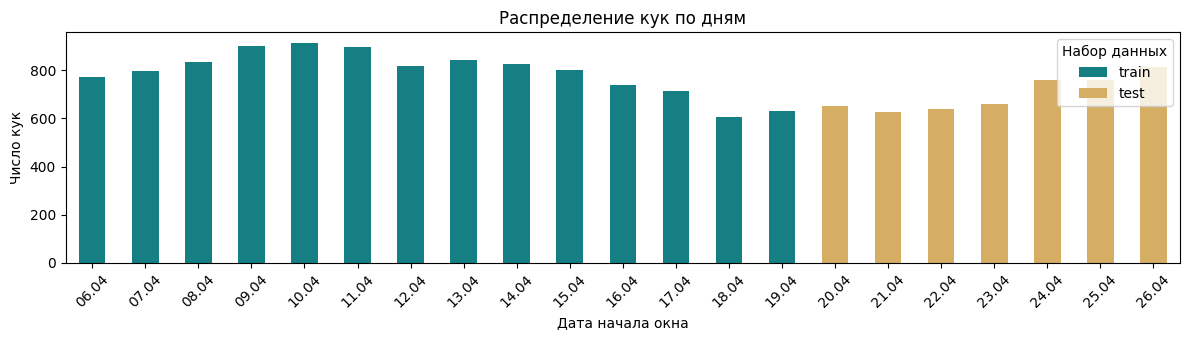

In [189]:
import matplotlib.pyplot as plt

daily_count = (
    meta
    .groupby(['window_start_ts', 'dataset'])
    .size()
    .unstack(fill_value=0)
)

ax = daily_count[['train', 'test']].plot.bar(
    stacked=True,
    figsize=(12, 3.5),
    color=['#157F83', '#D5AD63']
)

date_labels = [
    date.strftime('%d.%m')
    for date in daily_count.index
]

ax.set_xticklabels(
    date_labels,
    rotation=45
)

ax.set_xlabel('Дата начала окна')
ax.set_ylabel('Число кук')
ax.set_title('Распределение кук по дням')

ax.legend(title='Набор данных')

plt.tight_layout()
plt.show()

Все окна длятся 24 часа. Train занимает 6-19 апреля, test - 20-26 апреля. Пересечения по времени нет.

Test находится позже train. Валидация тоже должна идти по времени. Случайное разбиение может дать завышенную оценку.

In [190]:
train.groupby('window_start_ts').agg(
    total_cookies=('cookie_id', 'nunique'),
    positive_cookies=('target', 'sum')
)

,total_cookies,positive_cookies
window_start_ts,,
2026-04-06,772,68
2026-04-07,797,59
2026-04-08,834,70
2026-04-09,902,66
2026-04-10,912,82
2026-04-11,896,79
2026-04-12,817,67
2026-04-13,843,53
2026-04-14,826,70


Для финальной локальной проверки оставляем 17-19 апреля. За эти три дня набирается около 2 000 кук и 160 положительных примеров. Одного или двух дней мало для устойчивой оценки. Четыре дня сильнее уменьшают период разработки.

In [191]:
import numpy as np

HOLDOUT_START = pd.Timestamp('2026-04-17')
dev_labels = train.loc[train.window_start_ts < HOLDOUT_START, ['cookie_id', 'target']].set_index('cookie_id')
meta['period'] = np.where(meta.dataset.eq('test'), 'test',
                          np.where(meta.window_start_ts < HOLDOUT_START, 'разработка', 'финальная проверка'))
display(meta.groupby('period').agg(
    cookies=('cookie_id', 'size'), first_day=('window_start_ts', 'min'), last_day=('window_start_ts', 'max'))
    .rename(columns={'cookies':'Кук', 'first_day':'Начало', 'last_day':'Конец'}))

,Кук,Начало,Конец
period,,,
test,4909,2026-04-20,2026-04-26
разработка,9140,2026-04-06,2026-04-16
финальная проверка,1951,2026-04-17,2026-04-19


Связь признаков с target изучаем на 6-16 апреля. Внутри этого периода можно использовать два разбиения по времени.

- обучение 6-9 апреля, проверка 10-12 апреля
- обучение 6-12 апреля, проверка 13-16 апреля

Период 17-19 апреля не используется до выбора признаков и модели.

## Проверяем и очищаем события

### Ограничиваем историю разрешённым окном

События после конца окна неизвестны в момент предсказания. Их использование создаёт утечку из будущего. Считаем такие строки и исключаем их.

In [192]:
original_event_columns = events_raw.columns.tolist()
events_audit = events_raw.merge(
    meta[['cookie_id', 'window_start_ts', 'window_end_ts', 'cookie_created_at', 'dataset']],
    on='cookie_id', validate='many_to_one')
events_audit['position'] = np.select(
    [events_audit.event_ts < events_audit.window_start_ts,
     events_audit.event_ts == events_audit.window_end_ts,
     events_audit.event_ts > events_audit.window_end_ts],
    ['До окна', 'Ровно на конце', 'После конца'], default='Внутри окна')
display(pd.crosstab(events_audit.dataset, events_audit.position))


in_window = (events_audit.event_ts >= events_audit.window_start_ts) & (events_audit.event_ts < events_audit.window_end_ts)
events_window = events_audit.loc[in_window, original_event_columns].copy()
print('Исключено событий:', len(events_raw) - len(events_window))

position,Внутри окна,После конца,Ровно на конце
dataset,,,
test,89690,0,0
train,198436,40711,68


Исключено событий: 40779


Считаем положение событий относительно окна для каждого event_name.

In [193]:
event_window_table = pd.crosstab(events_audit.event_name, events_audit.position)
display(event_window_table)

position,Внутри окна,После конца,Ровно на конце
event_name,,,
captcha_shown,0,7926,2
contact_chat_open,5548,575,2
contact_message_sent,2823,258,0
contact_phone_show,10288,1025,3
favorite_add,17296,1744,9
item_view,108086,12712,19
login,5661,603,3
photo_swipe,33084,3420,13
search_results_view,89798,10590,14


Получили что captcha_shown находится только за рассматриваемым окном и этот признак использовать нельзя, так как это утечка и если считать капчу по всему events_raw, модель получит информацию, появившуюся после момента предсказания.

Поняли, что 40 779 событий не входят в разрешённое окно. Они присутствуют только у train. Среди них 68 событий ровно на правой границе. Все 7 928 показов капчи находятся вне окна.


### Разбираемся с повторами

Есть полные дубли строк и разные события с одинаковым временем. Полные дубли удаляем. Разные события в одну секунду сохраняем.

У событий нет уникального event_id, поэтому природу полного дубля нельзя установить точно. Влияние удаления проверяем отдельно.

In [194]:
full_duplicates = events_window.duplicated()
events = events_window.loc[~full_duplicates].copy()
print('Полных дублей:', full_duplicates.sum())
print('Осталось событий:', len(events))
print('Дополнительных строк с тем же cookie_id и временем:', events.duplicated(['cookie_id', 'event_ts']).sum())

counts_before = events_window.groupby('cookie_id').size()
counts_after = events.groupby('cookie_id').size()
duplicate_effect = pd.DataFrame({'До': counts_before, 'После': counts_after})
duplicate_effect['Удалено'] = duplicate_effect['До'] - duplicate_effect['После']
display(duplicate_effect[['До', 'После', 'Удалено']].describe(percentiles=[.5, .95, .99]).round(2))

Полных дублей: 4293
Осталось событий: 283833
Дополнительных строк с тем же cookie_id и временем: 1513


,До,После,Удалено
count,16000.00,16000.00,16000.00
mean,18.01,17.74,0.27
std,18.00,17.73,0.58
min,1.00,1.00,0.00
50%,12.00,12.00,0.00
95%,54.00,53.00,1.00
99%,89.00,87.00,2.00
max,191.00,187.00,6.00


Удалено 4 293 полных дубля. После очистки остаётся 1 513 повторных пар cookie_id и event_ts. Они могут быть разными действиями в одну секунду, поэтому они остаются в данных.

In [195]:
events['platform'].value_counts(dropna=False)

platform
desktop    40159
WEB        39740
Web        39689
web        39310
ANDROID    37013
Android    36802
android    36741
ios         3600
iphone      3597
iOS         3593
IOS         3589
Name: count, dtype: int64

### Приводим платформы к единому виду

Регистр и синонимы не должны создавать новые категории. desktop объединяем с web, iphone - с ios. Таблица соответствий показывает все изменения.

In [196]:
events['platform_raw'] = events.platform
platform_mapping = {'desktop': 'web', 'iphone': 'ios'}
events['platform'] = events.platform.astype('string').str.strip().str.lower().replace(platform_mapping)
display(pd.crosstab(events.platform_raw, events.platform))

platform_per_cookie = events.groupby('cookie_id').platform.nunique()
print('Число платформ у одной куки после нормализации:')
display(platform_per_cookie.value_counts().sort_index().rename_axis('Платформ').to_frame('Кук'))

platform,android,ios,web
platform_raw,,,
ANDROID,37013,0,0
Android,36802,0,0
IOS,0,3589,0
WEB,0,0,39740
Web,0,0,39689
android,36741,0,0
desktop,0,0,40159
iOS,0,3593,0
ios,0,3600,0


Число платформ у одной куки после нормализации:


,Кук
Платформ,
1,16000


In [197]:
events['platform'].value_counts(dropna=False)

platform
web        158898
android    110556
ios         14379
Name: count, dtype: Int64

После нормализации у каждой куки одна платформа. Число платформ на куку не даёт полезной информации. До нормализации оно отражало только разные варианты записи.

### Проверяем названия действий, порядок и допустимые значения

eid и event_name должны описывать одно действие. Для интервалов события должны идти по времени. Проверяем также целочисленность страниц поиска и согласованность координат.

In [198]:
action_dictionary = events.groupby(['eid', 'event_name']).size().rename('Событий').reset_index()
display(action_dictionary)

events = events.sort_values(['cookie_id', 'event_ts'], kind='stable').reset_index(drop=True)

,eid,event_name,Событий
0,100,search_results_view,88479
1,200,item_view,106448
2,210,photo_swipe,32570
3,220,seller_page_view,15343
4,300,contact_phone_show,10145
5,301,contact_chat_open,5479
6,303,contact_message_sent,2778
7,400,favorite_add,17012
8,500,login,5579


In [199]:
value_checks = pd.Series({
    'Неположительные страницы поиска': events.search_page.le(0).sum(),
    'Дробные страницы поиска': events.search_page.dropna().mod(1).ne(0).sum(),
    'Отрицательные ID объявлений': events.item_id.lt(0).sum(),
    'Разная заполненность X и Y': events.pointer_x.isna().ne(events.pointer_y.isna()).sum(),
    'Отрицательные координаты': events[['pointer_x', 'pointer_y']].lt(0).any(axis=1).sum(),
})
display(value_checks.to_frame('Строк'))
display(events[['search_page', 'pointer_x', 'pointer_y']].agg(['min', 'median', 'max']))

,Строк
Неположительные страницы поиска,0
Дробные страницы поиска,0
Отрицательные ID объявлений,0
Разная заполненность X и Y,0
Отрицательные координаты,0


,search_page,pointer_x,pointer_y
min,1.0,0.0,0.0
median,2.0,903.0,536.0
max,63.0,1920.0,1080.0


Названия и коды действий согласованы. События отсортированы. Реальный порядок внутри одной секунды неизвестен.

Страницы поиска, ID и координаты проходят базовые проверки. Диапазон координат не позволяет определить размер экрана.

### Отделяем ожидаемые пропуски от возможных ошибок

Номер страницы нужен для поиска, но не нужен для входа в аккаунт. Координаты могут отсутствовать из-за платформы. Заполненность смотрим отдельно по действиям и платформам.

In [200]:
missing_share = events.isna().mean()
fields_with_missing = missing_share[missing_share > 0].index.tolist()

print(fields_with_missing)

missing_by_action = (
    events[fields_with_missing]
    .isna()
    .groupby(events['event_name'])
    .mean()
    .mul(100)
)

display(missing_by_action.round(2))

['item_id', 'item_category', 'item_location', 'seller_type', 'search_query', 'search_page', 'pointer_x', 'pointer_y']


,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,
contact_chat_open,0.0,5.80,3.07,8.45,100.0,100.0,68.57,68.57
contact_message_sent,0.0,5.98,2.84,8.93,100.0,100.0,67.46,67.46
contact_phone_show,0.0,5.89,2.90,9.47,100.0,100.0,67.10,67.10
favorite_add,0.0,6.21,2.79,9.14,100.0,100.0,65.10,65.10
item_view,0.0,5.99,3.03,9.01,100.0,100.0,67.35,67.35
login,100.0,100.00,100.00,100.00,100.0,100.0,64.71,64.71
photo_swipe,0.0,5.85,3.19,8.77,100.0,100.0,65.67,65.67
search_results_view,100.0,5.96,3.10,100.00,0.0,0.0,66.91,66.91
seller_page_view,0.0,5.80,3.18,8.92,100.0,100.0,66.29,66.29


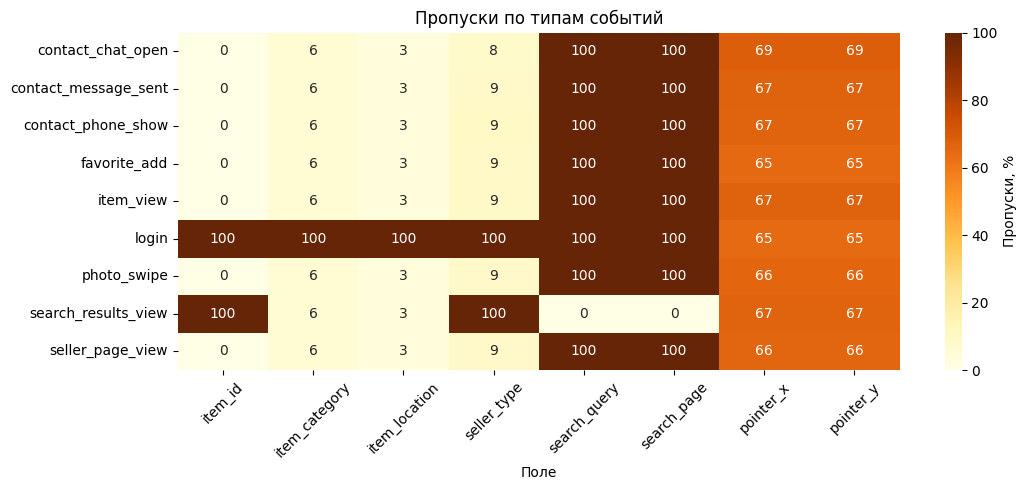

In [201]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    missing_by_action,
    annot=True,
    fmt='.0f',
    vmin=0,
    vmax=100,
    cmap='YlOrBr',
    cbar_kws={'label': 'Пропуски, %'},
    ax=ax
)
ax.set(title='Пропуски по типам событий', xlabel='Поле', ylabel='')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Проверяем зависимость пропусков от платформы и типа действия. Ожидаемое отсутствие поля не считаем ошибкой данных.

In [202]:
missing_by_platform = (
    events[['user_agent', 'pointer_x', 'pointer_y']]
    .isna()
    .groupby(events['platform'])
    .mean()
    .mul(100)
)
display(missing_by_platform.round(2))

relevant_missing = []

for action, fields in [
    ('item_view', ['item_id', 'item_category', 'item_location', 'seller_type']),
    ('search_results_view', ['search_query', 'search_page', 'item_category'])
]:
    subset = events.loc[events['event_name'].eq(action)]
    for field in fields:
        relevant_missing.append([
            action,
            field,
            len(subset),
            subset[field].isna().sum(),
            subset[field].isna().mean() * 100
        ])

relevant_missing = pd.DataFrame(
    relevant_missing,
    columns=['Действие', 'Поле', 'Событий', 'Пропусков', 'Пропусков, %']
)
display(relevant_missing.round(2))

,user_agent,pointer_x,pointer_y
platform,,,
android,0.0,100.00,100.00
ios,0.0,100.00,100.00
web,0.0,40.68,40.68


,Действие,Поле,Событий,Пропусков,"Пропусков, %"
0,item_view,item_id,106448,0,0.00
1,item_view,item_category,106448,6373,5.99
2,item_view,item_location,106448,3224,3.03
3,item_view,seller_type,106448,9589,9.01
4,search_results_view,search_query,88479,0,0.00
5,search_results_view,search_page,88479,0,0.00
6,search_results_view,item_category,88479,5276,5.96


### Одинаково ли заполняются поля у людей и ботов?

Поля объявления проверяем только для item_view. Координаты проверяем только на web. Доли считаем по кукам, чтобы активные куки не получили больший вес.

In [203]:
dev_events = events.loc[events['cookie_id'].isin(dev_labels.index)].merge(
    dev_labels.reset_index(),
    on='cookie_id',
    validate='many_to_one'
)

dev_item_views = dev_events.loc[dev_events['event_name'].eq('item_view')]
item_fields = ['item_category', 'item_location', 'seller_type']

item_missing_per_cookie = (
    dev_item_views.groupby('cookie_id')[item_fields]
    .apply(lambda x: x.isna().mean())
    .join(dev_labels)
)

item_missing_by_target = (
    item_missing_per_cookie.groupby('target')[item_fields]
    .mean()
    .mul(100)
)
item_missing_by_target.insert(
    0,
    'Кук с просмотрами',
    item_missing_per_cookie.groupby('target').size()
)

display(item_missing_by_target.rename(index={0: 'Человек', 1: 'Бот'}).round(2))

dev_web_events = dev_events.loc[dev_events['platform'].eq('web')]
pointer_missing_per_cookie = (
    dev_web_events.groupby('cookie_id')[['pointer_x', 'pointer_y']]
    .apply(lambda x: x.isna().mean())
    .join(dev_labels)
)

pointer_missing_by_target = (
    pointer_missing_per_cookie.groupby('target')[['pointer_x', 'pointer_y']]
    .mean()
    .mul(100)
)
pointer_missing_by_target.insert(
    0,
    'Кук на web',
    pointer_missing_per_cookie.groupby('target').size()
)

display(pointer_missing_by_target.rename(index={0: 'Человек', 1: 'Бот'}).round(2))

,Кук с просмотрами,item_category,item_location,seller_type
target,,,,
Человек,7796,6.00,3.01,9.15
Бот,725,6.53,2.85,8.76


,Кук на web,pointer_x,pointer_y
target,,,
Человек,4387,32.20,32.20
Бот,486,59.72,59.72


Пропуски item_category, item_location и seller_type почти не различаются между классами. item_category отсутствует у 6,00% просмотров человека и у 6,53% просмотров бота.

На web координаты отсутствуют у 32,20% событий человеческой куки и у 59,72% событий положительной куки. Разница заметная. Признак нужно использовать вместе с платформой.

Правила подготовки событий

- оставляем события с window_start_ts <= event_ts < window_end_ts
- удаляем полные дубли
- сохраняем разные события с одинаковым временем
- приводим платформу к общим категориям
- учитываем смысл поля перед заполнением пропуска
- сравниваем координаты внутри web
- ID используем для связей и подсчёта уникальных объектов

## Переходим от событий к одной строке на куку

Для каждой куки нужен один score. Смотрим короткую историю и собираем первые агрегаты.

In [204]:
example_candidates = counts_after[
    counts_after.between(7, 10) & counts_after.index.isin(dev_labels.index)
]
example_cookie = example_candidates.sort_index().index[0]

example_events = events.loc[
    events['cookie_id'].eq(example_cookie),
    ['event_ts', 'event_name', 'item_id']
]

display(example_events)

pd.DataFrame({
    'Событий': [len(example_events)],
    'Разных объявлений': [example_events['item_id'].nunique()],
    'Первая активность': [example_events['event_ts'].min()],
    'Последняя активность': [example_events['event_ts'].max()]
})

,event_ts,event_name,item_id
259,2026-04-13 11:50:42,item_view,1013205.0
260,2026-04-13 11:52:01,item_view,1013205.0
261,2026-04-13 11:52:40,item_view,1037962.0
262,2026-04-13 11:53:00,item_view,1013205.0
263,2026-04-13 11:53:31,search_results_view,NaN
264,2026-04-13 11:53:45,search_results_view,NaN
265,2026-04-13 11:53:54,item_view,1026315.0
266,2026-04-13 11:55:09,item_view,1028139.0
267,2026-04-13 11:55:42,item_view,1010537.0
268,2026-04-13 13:03:53,item_view,1026315.0


,Событий,Разных объявлений,Первая активность,Последняя активность
0,10,5,2026-04-13 11:50:42,2026-04-13 13:03:53


В выбранной истории десять событий и пять разных объявлений. Количество событий описывает объём активности. Число объявлений описывает разнообразие.

In [205]:
cookie_features = meta.set_index('cookie_id')[
    ['dataset', 'period', 'window_start_ts', 'age_days']
].copy()

by_cookie = events.groupby('cookie_id')

cookie_features['n_events'] = by_cookie.size().reindex(cookie_features.index, fill_value=0)
cookie_features['n_items'] = by_cookie['item_id'].nunique().reindex(cookie_features.index, fill_value=0)
cookie_features['platform'] = by_cookie['platform'].first()

print('Кук в таблице признаков:', len(cookie_features))
print('Кук без событий внутри окна:', cookie_features['n_events'].eq(0).sum())
display(cookie_features[['n_events', 'n_items', 'platform']].head())

Кук в таблице признаков: 16000
Кук без событий внутри окна: 0


,n_events,n_items,platform
cookie_id,,,
ck_54a059eb7d3ea68b,7,4,android
ck_7e4de46eeab82974,41,19,web
ck_9320229ef6304522,36,19,web
ck_30ccd25bc1714ed9,21,10,web
ck_a77c5f05948cdeef,28,16,web


cookie_features - рабочая таблица с одной строкой на куку. В ней есть все 16 000 кук, и у каждой осталось хотя бы одно событие внутри разрешённого окна.

## Смотрим баланс классов на периоде разработки

К этой таблице временно присоединяем метки только за 6-16 апреля. Метки 17-19 апреля пока не используем.

In [206]:
from metric import precision_at_recall

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

class_counts = analysis['target'].value_counts().sort_index()
class_table = pd.DataFrame({
    'Кук': class_counts,
    'Доля, %': class_counts / class_counts.sum() * 100
})
class_table.index = class_table.index.map({0: 'Человек', 1: 'Бот'})
display(class_table.round(2))

constant_score = precision_at_recall(
    analysis['target'],
    np.full(len(analysis), 0.5)
)
print(f'Метрика постоянного score: {constant_score:.4f}')

,Кук,"Доля, %"
target,,
Человек,8401,91.91
Бот,739,8.09


Метрика постоянного score: 0.0809


В периоде разработки 9 140 кук и 739 положительных примеров. Доля положительного класса равна 8,09%. Постоянный score даёт метрику 0,0809. Получаем базовый уровень без ранжирования.

## Боты действительно совершают больше событий?

Сравниваем квартиль, медиану, 95-й процентиль и максимум n_events. Среднее может сильно меняться из-за нескольких очень активных кук.

,count,25%,50%,75%,95%,max
target,,,,,,
Человек,8401.0,6.0,11.0,21.0,48.0,137.0
Бот,739.0,11.0,20.0,38.0,87.0,165.0


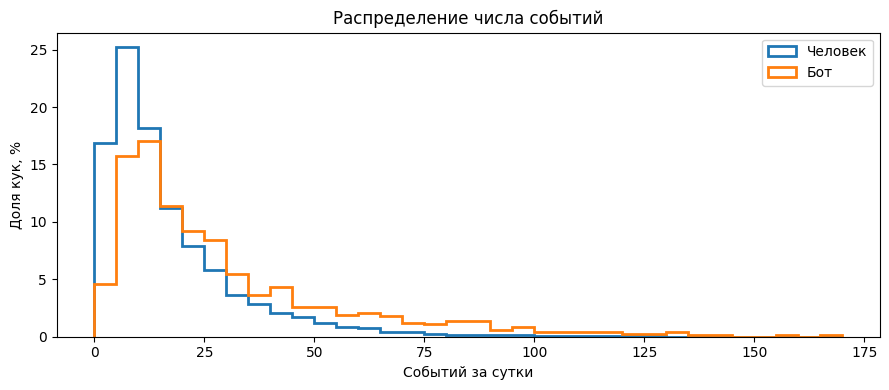

In [207]:
analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

events_summary = (
    analysis.groupby('target')['n_events']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    [['count', '25%', '50%', '75%', '95%', 'max']]
)
display(events_summary.rename(index={0: 'Человек', 1: 'Бот'}))

fig, ax = plt.subplots(figsize=(9, 4))

for target, label in [(0, 'Человек'), (1, 'Бот')]:
    values = analysis.loc[analysis['target'].eq(target), 'n_events']
    ax.hist(
        values,
        bins=np.arange(0, 171, 5),
        weights=np.ones(len(values)) * 100 / len(values),
        histtype='step',
        linewidth=2,
        label=label
    )

ax.set(xlabel='Событий за сутки', ylabel='Доля кук, %', title='Распределение числа событий')
ax.legend()
plt.tight_layout()
plt.show()

Медиана равна 20 событиям у ботов и 11 у людей. Значения 95-го процентиля равны 87 и 48. Распределения пересекаются, поэтому одного порога по n_events недостаточно.

Отдельно считаем короткие истории. Для них часть признаков ритма и последовательности не определена.

In [208]:
short_histories = analysis.groupby('target')['n_events'].agg(
    total='size',
    one_event=lambda x: x.eq(1).sum(),
    up_to_three=lambda x: x.le(3).sum()
)

display(short_histories.rename(index={0: 'Человек', 1: 'Бот'}))

,total,one_event,up_to_three
target,,,
Человек,8401,208,978
Бот,739,4,20


В данных 212 кук с одним событием. Среди них 4 положительных. Эти куки остаются в выборке. Количество событий для них известно, интервал между событиями отсутствует.

## Как активность распределена внутри суток?

Считаем число активных часов и максимальное количество событий за минуту.

In [209]:
events['minute'] = events['event_ts'].dt.floor('min')
events['hour'] = events['event_ts'].dt.floor('h')

active_hours = events.groupby('cookie_id')['hour'].nunique()
events_per_minute = events.groupby(['cookie_id', 'minute']).size()
max_events_minute = events_per_minute.groupby('cookie_id').max()

cookie_features['active_hours'] = active_hours.reindex(cookie_features.index, fill_value=0)
cookie_features['max_events_minute'] = max_events_minute.reindex(cookie_features.index, fill_value=0)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

activity_summary = analysis.groupby('target')[
    ['active_hours', 'max_events_minute']
].agg(['median', lambda x: x.quantile(0.95)])

activity_summary.columns = ['active_hours_median', 'active_hours_p95',
                            'max_events_minute_median', 'max_events_minute_p95']
display(activity_summary.rename(index={0: 'Человек', 1: 'Бот'}))

,active_hours_median,active_hours_p95,max_events_minute_median,max_events_minute_p95
target,,,,
Человек,3.0,8.0,2.0,5.0
Бот,3.0,7.0,4.0,10.1


Число активных часов у классов близко и слабо разделяет классы. Максимум событий за минуту показывает локальную плотность активности. Оба признака сохраняем.

## Сколько времени проходит между действиями?

Для каждого события считаем паузу после предыдущего события той же куки. Затем собираем статистики по куке.

,count,25%,50%,75%,95%
target,,,,,
Человек,8193.0,38.0,61.0,103.0,780.50
Бот,735.0,14.0,25.0,54.0,529.35


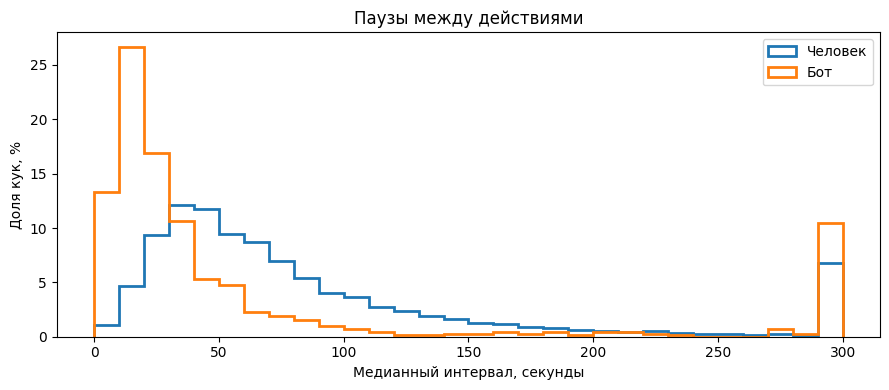

In [210]:
events['gap_seconds'] = (
    events.groupby('cookie_id')['event_ts']
    .diff()
    .dt.total_seconds()
)

gaps = events.groupby('cookie_id')['gap_seconds']

cookie_features['gap_median'] = gaps.median()
cookie_features['gap_q25'] = gaps.quantile(0.25)
cookie_features['gap_q75'] = gaps.quantile(0.75)
cookie_features['gap_iqr'] = cookie_features['gap_q75'] - cookie_features['gap_q25']
cookie_features['zero_gap_share'] = gaps.apply(lambda x: x.dropna().eq(0).mean())

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

gap_summary = (
    analysis.groupby('target')['gap_median']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    [['count', '25%', '50%', '75%', '95%']]
)
display(gap_summary.rename(index={0: 'Человек', 1: 'Бот'}))

fig, ax = plt.subplots(figsize=(9, 4))

for target, label in [(0, 'Человек'), (1, 'Бот')]:
    values = analysis.loc[analysis['target'].eq(target), 'gap_median'].dropna().clip(upper=300)
    ax.hist(
        values,
        bins=np.arange(0, 310, 10),
        weights=np.ones(len(values)) * 100 / len(values),
        histtype='step',
        linewidth=2,
        label=label
    )

ax.set(xlabel='Медианный интервал, секунды', ylabel='Доля кук, %', title='Паузы между действиями')
ax.legend()
plt.tight_layout()
plt.show()

Медианная пауза равна примерно 25 секундам у ботов и 61 секунде у людей. Разница заметная. На графике значения больше 300 секунд попадают в последний интервал. Таблица рассчитана по исходным значениям.

Нулевые интервалы могут появиться из-за дублей. Сравниваем их до и после очистки.

In [211]:
raw_sorted = events_window.sort_values(['cookie_id', 'event_ts'], kind='stable').copy()
raw_sorted['gap_seconds'] = raw_sorted.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()

zero_before = raw_sorted.groupby('cookie_id')['gap_seconds'].apply(lambda x: x.eq(0).any())
zero_after = events.groupby('cookie_id')['gap_seconds'].apply(lambda x: x.eq(0).any())

zero_gap_comparison = pd.DataFrame({
    'До удаления дублей': zero_before,
    'После удаления дублей': zero_after
}).loc[dev_labels.index].join(dev_labels)

zero_gap_rates = zero_gap_comparison.groupby('target')[
    ['До удаления дублей', 'После удаления дублей']
].mean().mul(100)

display(zero_gap_rates.rename(index={0: 'Человек', 1: 'Бот'}).round(2))

,До удаления дублей,После удаления дублей
target,,
Человек,25.58,8.05
Бот,36.27,3.65


До очистки нулевой интервал чаще встречался у положительного класса. После очистки направление связи изменилось. Технические повторы создавали ложный сигнал. Признаки ритма считаем после удаления дублей.

## Сколько отдельных сессий было внутри суток?

Новая сессия начинается после паузы больше 30 минут. Границу можно изменить и сравнить на валидации.

### Что ещё можно узнать из пауз?

Медиана показывает типичный интервал, но не описывает самые быстрые действия и общий разброс. Добавим короткий и длинный квантили, стандартное отклонение, долю пауз не больше 10 секунд и долю событий в самой активной минуте.

In [212]:
gap_groups = events.groupby('cookie_id')['gap_seconds']

cookie_features['gap_p10'] = gap_groups.quantile(0.10)
cookie_features['gap_p90'] = gap_groups.quantile(0.90)
cookie_features['gap_std'] = gap_groups.std()

known_gaps = events.loc[events['gap_seconds'].notna()]
fast_gap_share = (
    known_gaps['gap_seconds'].le(10)
    .groupby(known_gaps['cookie_id'])
    .mean()
)

cookie_features['fast_gap_share'] = fast_gap_share
cookie_features['active_minute_share'] = (
    cookie_features['max_events_minute'] / cookie_features['n_events']
)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

extra_rhythm_summary = analysis.groupby('target')[
    ['gap_p10', 'gap_p90', 'gap_std', 'fast_gap_share', 'active_minute_share']
].median()

display(extra_rhythm_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(3))

,gap_p10,gap_p90,gap_std,fast_gap_share,active_minute_share
target,,,,,
Человек,17.0,1663.5,1751.089,0.077,0.200
Бот,9.2,124.2,1372.276,0.167,0.167


Десятый процентиль пауз равен 17 секундам у людей и 9,2 секунды у ботов. Доля пауз не больше 10 секунд равна 7,7% и 16,7%.

Девяностый процентиль равен 1663,5 секунды у людей и 124,2 секунды у ботов. Положительные куки действуют более плотным потоком. У кук с одним событием gap признаки остаются пропусками.

In [213]:
new_session = events['gap_seconds'].isna() | events['gap_seconds'].gt(30 * 60)
events['session'] = new_session.groupby(events['cookie_id']).cumsum()

sessions = events.groupby(['cookie_id', 'session']).agg(
    first_event=('event_ts', 'min'),
    last_event=('event_ts', 'max'),
    n_events=('event_ts', 'size')
)
sessions['duration_minutes'] = (
    sessions['last_event'] - sessions['first_event']
).dt.total_seconds() / 60

cookie_features['n_sessions'] = sessions.groupby(level=0).size().reindex(cookie_features.index, fill_value=0)
cookie_features['session_duration_median'] = sessions.groupby(level=0)['duration_minutes'].median()

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

session_summary = analysis.groupby('target')[
    ['n_sessions', 'session_duration_median']
].median()
display(session_summary.rename(index={0: 'Человек', 1: 'Бот'}))

,n_sessions,session_duration_median
target,,
Человек,2.0,3.500000
Бот,2.0,2.808333


Медианное число сессий одинаково - две. Этот признак выглядит слабее медианной паузы, но может дополнять общий объём и продолжительность активности.

## В какие часы происходит активность?

Час берём из исходного event_ts. В данных не указана временная зона пользователя, поэтому профиль описывает только время в файле и не должен интерпретироваться как режим сна конкретного человека.

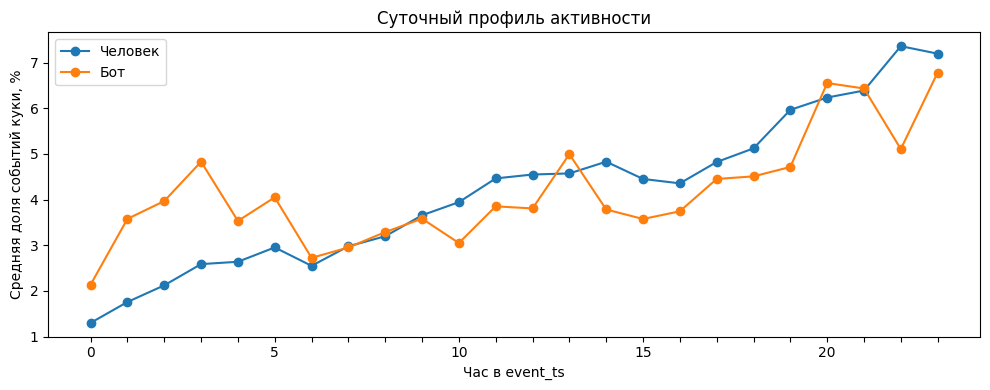

In [214]:
dev_events = events.loc[events['cookie_id'].isin(dev_labels.index)].copy()
dev_events['event_hour'] = dev_events['event_ts'].dt.hour

hour_counts = pd.crosstab(dev_events['cookie_id'], dev_events['event_hour'])
hour_counts = hour_counts.reindex(columns=range(24), fill_value=0)
hour_shares = hour_counts.div(hour_counts.sum(axis=1), axis=0)

hour_profile = (
    hour_shares
    .join(dev_labels)
    .groupby('target')
    .mean()
    .T
    .mul(100)
)

ax = hour_profile.plot(figsize=(10, 4), marker='o')
ax.set(
    xlabel='Час в event_ts',
    ylabel='Средняя доля событий куки, %',
    title='Суточный профиль активности'
)
ax.set_xticks(range(24))
ax.legend(['Человек', 'Бот'])
plt.tight_layout()
plt.show()

Почасовой профиль может меняться вместе с составом трафика. Его можно представить долями событий по нескольким диапазонам времени и проверить на будущих днях.

## Какие действия составляют историю?

Для каждого события считаем количество и долю. Количество описывает объём. Доля описывает состав истории.

,Человек,Бот
contact_chat_open,1.69,1.83
contact_message_sent,0.80,1.05
contact_phone_show,3.13,3.18
favorite_add,6.80,3.24
item_view,36.33,42.32
login,2.32,1.03
photo_swipe,12.73,7.88
search_results_view,30.91,33.30
seller_page_view,5.28,6.17


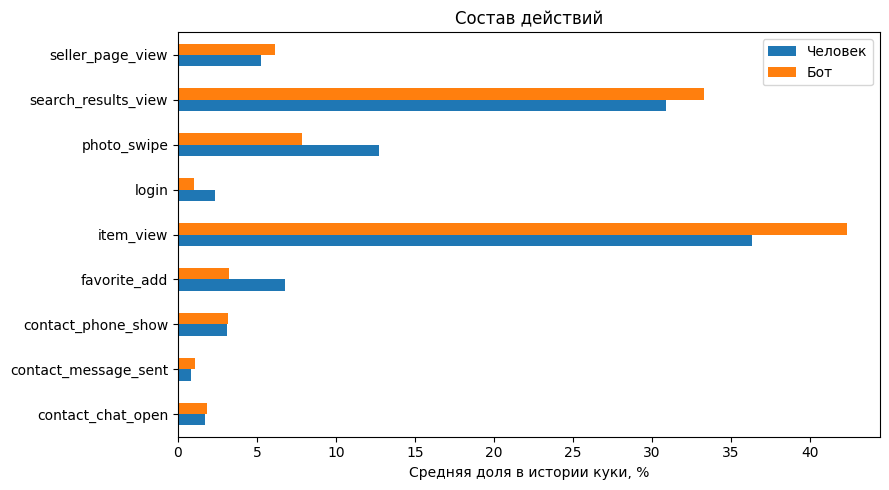

In [215]:
action_counts = pd.crosstab(events['cookie_id'], events['event_name'])
action_counts = action_counts.reindex(cookie_features.index, fill_value=0)

for action in action_counts.columns:
    cookie_features['n_' + action] = action_counts[action]
    cookie_features['share_' + action] = action_counts[action] / cookie_features['n_events']

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

share_columns = ['share_' + action for action in action_counts.columns]
action_mix = analysis.groupby('target')[share_columns].mean().T.mul(100)
action_mix.index = action_mix.index.str.replace('share_', '', regex=False)
action_mix.columns = ['Человек', 'Бот']

display(action_mix.round(2))

ax = action_mix.plot.barh(figsize=(9, 5))
ax.set(xlabel='Средняя доля в истории куки, %', ylabel='', title='Состав действий')
plt.tight_layout()
plt.show()

У положительного класса выше доля item_view. У людей выше доли favorite_add и photo_swipe. Количество и долю храним вместе. Доля по 5 событиям менее надёжна, чем такая же доля по 100 событиям.

## Отличаются ли контактные действия?

К контактам относим показ телефона, открытие чата и отправку сообщения. Сохраняем количество контактов и наличие хотя бы одного контакта.

In [216]:
contact_columns = [
    'n_contact_phone_show',
    'n_contact_chat_open',
    'n_contact_message_sent'
]

cookie_features['n_contacts'] = cookie_features[contact_columns].sum(axis=1)
cookie_features['has_contact'] = cookie_features['n_contacts'].gt(0)
cookie_features['contacts_per_view'] = (
    cookie_features['n_contacts'] /
    cookie_features['n_item_view'].replace(0, np.nan)
)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

contact_summary = analysis.groupby('target').agg(
    cookies=('target', 'size'),
    cookies_with_contact=('has_contact', 'sum'),
    contact_rate=('has_contact', 'mean'),
    contacts_median=('n_contacts', 'median')
)
contact_summary['contact_rate'] *= 100

display(contact_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(2))

,cookies,cookies_with_contact,contact_rate,contacts_median
target,,,,
Человек,8401,4051,48.22,0.0
Бот,739,374,50.61,1.0


Хотя бы один контакт есть примерно у половины обеих групп. Гипотеза об отсутствии контактов у ботов не подтверждается. Сервисы из постановки могут собирать контакты.

contacts_per_view остаётся пропуском при отсутствии item_view. Деление на ноль не имеет смысла.

## Куки смотрят новые объявления или возвращаются к старым?

В расчёт входят только item_view. У поисковых событий нет item_id.

In [217]:
views = events.loc[events['event_name'].eq('item_view')].copy()
views_by_cookie = views.groupby('cookie_id')

known_item_views = views_by_cookie['item_id'].count()
unique_viewed_items = views_by_cookie['item_id'].nunique()

cookie_features['known_item_views'] = known_item_views.reindex(cookie_features.index, fill_value=0)
cookie_features['unique_viewed_items'] = unique_viewed_items.reindex(cookie_features.index, fill_value=0)
cookie_features['repeat_view_share'] = 1 - (
    cookie_features['unique_viewed_items'] /
    cookie_features['known_item_views'].replace(0, np.nan)
)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

view_summary = analysis.groupby('target')[
    ['unique_viewed_items', 'repeat_view_share']
].agg(['count', 'median', 'mean'])
display(view_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(3))

unique_viewed_items                repeat_view_share              
                      count median    mean             count median   mean
target                                                                    
Человек                8401    4.0   5.251              7796  0.000  0.103
Бот                     739    7.0  10.124               725  0.125  0.135

unique_viewed_items растёт вместе с числом просмотров. repeat_view_share показывает частоту возврата к уже просмотренным ID. Для коротких историй долю повторов используем вместе с количеством просмотров.

## Насколько узкие интересы по категориям и локациям?

Считаем долю самой частой категории и локации среди известных значений. Пропуски не входят в знаменатель.

In [218]:
known_category = views_by_cookie['item_category'].count()
category_counts = views.dropna(subset=['item_category']).groupby(
    ['cookie_id', 'item_category']
).size()
largest_category = category_counts.groupby(level=0).max()

cookie_features['unique_categories'] = views_by_cookie['item_category'].nunique().reindex(
    cookie_features.index, fill_value=0
)
cookie_features['category_focus'] = largest_category / known_category.replace(0, np.nan)

known_location = views_by_cookie['item_location'].count()
location_counts = views.dropna(subset=['item_location']).groupby(
    ['cookie_id', 'item_location']
).size()
largest_location = location_counts.groupby(level=0).max()

cookie_features['unique_locations'] = views_by_cookie['item_location'].nunique().reindex(
    cookie_features.index, fill_value=0
)
cookie_features['location_focus'] = largest_location / known_location.replace(0, np.nan)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

interest_summary = analysis.groupby('target')[
    ['unique_categories', 'category_focus', 'unique_locations', 'location_focus']
].median()
display(interest_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(3))

,unique_categories,category_focus,unique_locations,location_focus
target,,,,
Человек,2.0,0.800,2.0,0.556
Бот,1.0,0.983,5.0,0.385


Положительный класс сильнее сосредоточен на основной категории и охватывает больше локаций. Автоматизированный сбор может быть узким по теме и широким по географии. Проверяем разницу среди кук с похожим числом просмотров.

## Отличается ли тип продавца?

Для просмотров объявлений считаем долю событий с seller_type = pro среди тех строк, где тип продавца известен. Отдельный знаменатель нужен из-за пропусков.

In [219]:
display(views['seller_type'].value_counts(dropna=False).to_frame('Событий'))

known_seller = views_by_cookie['seller_type'].count()
pro_views = views.loc[views['seller_type'].eq('pro')].groupby('cookie_id').size()

cookie_features['pro_seller_share'] = (
    pro_views / known_seller.replace(0, np.nan)
)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

seller_summary = analysis.groupby('target')['pro_seller_share'].agg(
    cookies='count',
    median='median',
    mean='mean'
)
display(seller_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(3))

,Событий
seller_type,
private,55698
pro,41161
NaN,9589


,cookies,median,mean
target,,,
Человек,6033,0.5,0.523
Бот,659,0.5,0.517


Медианная доля просмотров профессиональных продавцов одинакова. Средние значения тоже почти не различаются. Признак можно оставить, но он не относится к основным гипотезам.

## Как используется поиск?

В запросах убираем пробелы по краям, приводим текст к нижнему регистру и схлопываем повторные пробелы. Считаем число запросов, максимальную страницу и долю страниц 5 или глубже.

In [220]:
searches = events.loc[events['event_name'].eq('search_results_view')].copy()

searches['query_normalized'] = (
    searches['search_query']
    .astype('string')
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .replace('', pd.NA)
)

searches_by_cookie = searches.groupby('cookie_id')
known_pages = searches_by_cookie['search_page'].count()
deep_pages = searches.loc[searches['search_page'].ge(5)].groupby('cookie_id').size()

cookie_features['has_search'] = cookie_features['n_search_results_view'].gt(0)
cookie_features['unique_queries'] = searches_by_cookie['query_normalized'].nunique().reindex(
    cookie_features.index, fill_value=0
)
cookie_features['max_search_page'] = searches_by_cookie['search_page'].max()
cookie_features['deep_search_share'] = deep_pages / known_pages.replace(0, np.nan)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

search_summary = analysis.groupby('target').agg(
    cookies=('target', 'size'),
    has_search=('has_search', 'mean'),
    unique_queries_median=('unique_queries', 'median'),
    max_page_median=('max_search_page', 'median'),
    deep_page_share_median=('deep_search_share', 'median')
)
search_summary['has_search'] *= 100

display(search_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(3))

,cookies,has_search,unique_queries_median,max_page_median,deep_page_share_median
target,,,,,
Человек,8401,91.441,3.0,4.0,0.250
Бот,739,95.670,4.0,7.0,0.333


Поиск встречается в обеих группах, но положительные куки в среднем доходят глубже. Максимальная страница зависит от количества поисковых событий, поэтому далее сравним глубину внутри групп с похожим объёмом поиска.

Отдельно смотрим переход на следующую страницу того же запроса. Сравниваем соседние поисковые события с разным временем и одинаковым нормализованным запросом.

In [221]:
searches['previous_ts'] = searches.groupby('cookie_id')['event_ts'].shift()
searches['previous_query'] = searches.groupby('cookie_id')['query_normalized'].shift()
searches['previous_page'] = searches.groupby('cookie_id')['search_page'].shift()

comparable_search = (
    searches['previous_ts'].notna() &
    searches['event_ts'].gt(searches['previous_ts']) &
    searches['query_normalized'].notna() &
    searches['query_normalized'].eq(searches['previous_query']) &
    searches['search_page'].notna() &
    searches['previous_page'].notna()
)

next_page = comparable_search & searches['search_page'].eq(searches['previous_page'] + 1)

comparable_count = searches.loc[comparable_search].groupby('cookie_id').size()
next_page_count = searches.loc[next_page].groupby('cookie_id').size()

cookie_features['comparable_search_pairs'] = comparable_count.reindex(
    cookie_features.index, fill_value=0
)
cookie_features['next_page_share'] = (
    next_page_count / comparable_count.replace(0, np.nan)
)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

next_page_summary = analysis.groupby('target')['next_page_share'].agg(
    cookies='count',
    median='median',
    mean='mean'
)
display(next_page_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(3))

,cookies,median,mean
target,,,
Человек,452,1.0,0.742
Бот,111,0.3,0.379


Подходящие пары есть у 563 кук периода разработки. Медианная доля переходов на следующую страницу равна 1,0 у людей и 0,3 у ботов. Охват маленький.

Пропуск означает отсутствие подходящей пары событий. next_page_share используем вместе с comparable_search_pairs.

## Есть ли повторяющиеся последовательности действий?

Порядок событий с одинаковым event_ts неизвестен. Соседние действия сравниваем только при увеличении времени.

In [222]:
events['previous_event'] = events.groupby('cookie_id')['event_name'].shift()
events['previous_ts'] = events.groupby('cookie_id')['event_ts'].shift()

valid_transition = events['previous_ts'].notna() & events['event_ts'].gt(events['previous_ts'])
same_action = valid_transition & events['event_name'].eq(events['previous_event'])

transition_count = events.loc[valid_transition].groupby('cookie_id').size()
same_action_count = events.loc[same_action].groupby('cookie_id').size()

cookie_features['same_action_share'] = (
    same_action_count / transition_count.replace(0, np.nan)
)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

sequence_summary = analysis.groupby('target')['same_action_share'].agg(
    cookies='count',
    median='median',
    mean='mean'
)
display(sequence_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(3))

,cookies,median,mean
target,,,
Человек,6915,0.267,0.300
Бот,693,0.328,0.335


same_action_share показывает долю переходов с повторением предыдущего действия. Пропуск означает отсутствие переходов с разными timestamps. Отсутствие наблюдений и нулевая доля повторов имеют разный смысл.

## Связан ли возраст куки с target?

age_days известен к концу окна. Сравниваем распределение и долю кук младше недели.

### Повторяются ли целые сценарии у разных кук?

Автоматизированный сервис может запускать один и тот же сценарий много раз. Сравним полные последовательности event_name на периоде разработки. Истории короче пяти событий убираем из этой проверки, потому что короткие совпадения слишком обычны.

In [223]:
dev_sequences = (
    events.loc[events['cookie_id'].isin(dev_labels.index)]
    .groupby('cookie_id')['event_name']
    .agg(tuple)
)

dev_sequences = dev_sequences.loc[dev_sequences.map(len).ge(5)]
sequence_counts = dev_sequences.value_counts()

sequence_repetition = pd.DataFrame({
    'sequence_frequency': dev_sequences.map(sequence_counts),
    'sequence_length': dev_sequences.map(len)
}).join(dev_labels)

sequence_summary = sequence_repetition.groupby('target').agg(
    cookies=('target', 'size'),
    repeated_sequence_share=('sequence_frequency', lambda x: x.gt(1).mean() * 100),
    median_frequency=('sequence_frequency', 'median'),
    max_frequency=('sequence_frequency', 'max')
)

display(sequence_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(2))

top_sequences = sequence_counts.head(10).rename('Кук').reset_index()
top_sequences['Длина'] = top_sequences['event_name'].map(len)
top_sequences['Последовательность'] = top_sequences['event_name'].map(
    lambda x: ' -> '.join(x)
)

display(top_sequences[['Кук', 'Длина', 'Последовательность']])

,cookies,repeated_sequence_share,median_frequency,max_frequency
target,,,,
Человек,6986,3.15,1.0,7
Бот,705,2.13,1.0,7


,Кук,Длина,Последовательность
0,7,5,item_view -> item_view -> item_view -> item_vi...
1,7,5,item_view -> item_view -> item_view -> item_vi...
2,7,5,item_view -> search_results_view -> item_view ...
3,6,5,item_view -> search_results_view -> item_view ...
4,5,5,item_view -> search_results_view -> item_view ...
5,5,6,item_view -> item_view -> search_results_view ...
6,5,5,search_results_view -> search_results_view -> ...
7,4,5,item_view -> search_results_view -> item_view ...
8,4,5,item_view -> item_view -> search_results_view ...
9,3,5,item_view -> item_view -> item_view -> photo_s...


Полностью повторяющиеся истории есть у 3,15% человеческих кук и у 2,13% положительных кук с пятью и более событиями. Гипотеза об автоматизации не подтверждается. Признак не добавляем.

Если частота шаблона понадобится позднее, её нужно считать на обучающей части и переносить на валидацию и test.

,cookies,median_days,under_week,p95_days
target,,,,
Человек,8401,63.29,21.15,204.40
Бот,739,22.51,46.96,179.37


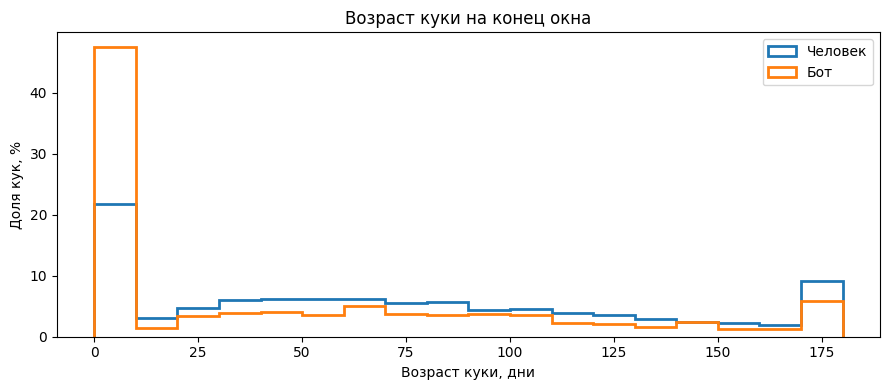

In [224]:
analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

age_summary = analysis.groupby('target')['age_days'].agg(
    cookies='size',
    median_days='median',
    under_week=lambda x: x.lt(7).mean() * 100,
    p95_days=lambda x: x.quantile(0.95)
)
display(age_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(2))

fig, ax = plt.subplots(figsize=(9, 4))

for target, label in [(0, 'Человек'), (1, 'Бот')]:
    values = analysis.loc[analysis['target'].eq(target), 'age_days'].clip(upper=180)
    ax.hist(
        values,
        bins=np.arange(0, 190, 10),
        weights=np.ones(len(values)) * 100 / len(values),
        histtype='step',
        linewidth=2,
        label=label
    )

ax.set(xlabel='Возраст куки, дни', ylabel='Доля кук, %', title='Возраст куки на конец окна')
ax.legend()
plt.tight_layout()
plt.show()

Медианный возраст положительных кук равен 22,5 дня, человеческих - 63,3 дня. Доля кук младше недели равна 47% и 21%.

Возраст может быть связан со способом формирования выборки. Проверяем его по дням и на отложенном периоде.

## Есть ли разница между платформами?

Для каждой платформы выводим размер группы, число положительных кук и их долю.

In [225]:
platform_summary = analysis.groupby('platform')['target'].agg(
    cookies='size',
    bots='sum',
    bot_rate='mean'
)
platform_summary['bot_rate'] *= 100

display(platform_summary.sort_values('cookies', ascending=False).round(2))

,cookies,bots,bot_rate
platform,,,
web,4873,486,9.97
android,3795,231,6.09
ios,472,22,4.66


Доля положительного класса различается по платформам. Платформа также связана с наличием координат. Используем её как категориальный признак и как разрез для проверки поведения.

## Что можно взять из User-Agent без сложного парсинга?

Считаем число разных User-Agent и наличие явных технических маркеров. Маркер имеет ограниченный охват и не используется как готовое правило.

In [226]:
cookie_features['n_user_agents'] = events.groupby('cookie_id')['user_agent'].nunique()

automation_pattern = (
    r'headlesschrome|python-requests|python-urllib|scrapy|curl/|'
    r'go-http-client|node-fetch|wget|aiohttp|httpx'
)

events['has_automation_marker'] = (
    events['user_agent']
    .fillna('')
    .str.lower()
    .str.contains(automation_pattern, regex=True)
)

cookie_features['has_automation_marker'] = events.groupby('cookie_id')[
    'has_automation_marker'
].any()

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')

ua_summary = analysis.groupby('has_automation_marker')['target'].agg(
    cookies='size',
    bots='sum',
    bot_rate='mean'
)
ua_summary['bot_rate'] *= 100

display(ua_summary.round(2))

covered_bots = analysis.loc[analysis['has_automation_marker'], 'target'].sum()
print('Охват положительного класса:', round(covered_bots / analysis['target'].sum() * 100, 2), '%')

,cookies,bots,bot_rate
has_automation_marker,,,
False,8743,638,7.30
True,397,101,25.44


Охват положительного класса: 13.67 %


Явные технические маркеры дают повышенную долю положительного класса, но находят лишь небольшую часть всех ботов. Их можно добавить в модель, но нельзя использовать как единственное правило.

## Координаты несут сигнал или только показывают платформу?

На Android и iOS координаты отсутствуют всегда, поэтому сравниваем их только среди web-кук.

In [227]:
pointer_count = (
    events.dropna(subset=['pointer_x', 'pointer_y'])
    .groupby('cookie_id')
    .size()
)

cookie_features['pointer_share'] = (
    pointer_count.reindex(cookie_features.index, fill_value=0) /
    cookie_features['n_events']
)

analysis = cookie_features.loc[dev_labels.index].join(dev_labels, validate='one_to_one')
web_analysis = analysis.loc[analysis['platform'].eq('web')]

pointer_summary = web_analysis.groupby('target')['pointer_share'].agg(
    cookies='size',
    mean='mean',
    median='median',
    any_pointer=lambda x: x.gt(0).mean()
)
pointer_summary[['mean', 'median', 'any_pointer']] *= 100

display(pointer_summary.rename(index={0: 'Человек', 1: 'Бот'}).round(2))

,cookies,mean,median,any_pointer
target,,,,
Человек,4387,67.80,93.33,71.44
Бот,486,40.28,0.00,42.39


Внутри web координаты у положительного класса встречаются реже. Сигнал может зависеть от способа сбора событий. В модель передаём долю заполненных координат и платформу.

## Не объясняется ли короткая пауза просто большим числом событий?

Разбиваем куки по числу событий и сравниваем медианную паузу внутри каждого диапазона.

In [228]:
analysis['activity_group'] = pd.cut(
    analysis['n_events'],
    bins=[0, 5, 10, 20, 50, np.inf],
    labels=['1-5', '6-10', '11-20', '21-50', '>50']
)

rhythm_control = analysis.groupby(
    ['activity_group', 'target'], observed=True
).agg(
    cookies=('target', 'size'),
    gap_median=('gap_median', 'median')
)

display(rhythm_control.round(2))

cookies  gap_median
activity_group target                     
1-5            0          1887        93.0
               1            67        92.0
6-10           0          1997        74.0
               1           116        59.5
11-20          0          2275        61.0
               1           196        31.5
21-50          0          1872        48.0
               1           233        20.0
>50            0           370        33.0
               1           127        10.0

В диапазонах 11-20 и 21-50 событий положительные куки действуют быстрее. Разница пауз не объясняется только общим числом событий. Для коротких историй оценка ритма менее надёжна.

## Сохраняются ли различия интересов при похожем числе просмотров?

In [229]:
analysis['view_group'] = pd.cut(
    analysis['n_item_view'],
    bins=[-1, 0, 2, 5, 10, 20, np.inf],
    labels=['0', '1-2', '3-5', '6-10', '11-20', '>20']
)

view_control = analysis.groupby(
    ['view_group', 'target'], observed=True
).agg(
    cookies=('target', 'size'),
    category_focus=('category_focus', 'median'),
    location_focus=('location_focus', 'median'),
    unique_locations=('unique_locations', 'median')
)

display(view_control.round(3))

cookies  category_focus  location_focus  unique_locations
view_group target                                                           
0          0           605             NaN             NaN               0.0
           1            14             NaN             NaN               0.0
1-2        0          2089           1.000           1.000               1.0
           1            75           1.000           1.000               1.0
3-5        0          2402           0.750           0.600               2.0
           1           177           1.000           0.500               3.0
6-10       0          1906           0.667           0.444               4.0
           1           178           0.857           0.375               5.0
11-20      0          1097           0.600           0.368               7.0
           1           155           0.917           0.286               8.0
>20        0           302           0.521           0.357              10.5
           1           140           0.922           0.230              13.0

При большом числе просмотров положительный класс сильнее сосредоточен на одной категории и охватывает больше локаций. Разница сохраняется после контроля числа просмотров.

## Сохраняется ли глубокий поиск при похожем числе поисковых событий?

In [230]:
search_analysis = analysis.loc[analysis['has_search']].copy()
search_analysis['search_group'] = pd.cut(
    search_analysis['n_search_results_view'],
    bins=[0, 2, 5, 10, 20, np.inf],
    labels=['1-2', '3-5', '6-10', '11-20', '>20']
)

search_control = search_analysis.groupby(
    ['search_group', 'target'], observed=True
).agg(
    cookies=('target', 'size'),
    max_page=('max_search_page', 'median'),
    deep_share=('deep_search_share', 'median')
)

display(search_control.round(3))

cookies  max_page  deep_share
search_group target                               
1-2          0          2481       2.0       0.500
             1           113       2.0       0.500
3-5          0          2498       3.0       0.250
             1           164       4.0       0.250
6-10         0          1697       5.0       0.167
             1           192       7.0       0.286
11-20        0           862       7.0       0.182
             1           133      11.0       0.333
>20          0           144      10.0       0.190
             1           105      20.0       0.469

Различие глубины поиска сохраняется в нескольких диапазонах объёма. max_search_page и deep_search_share описывают не только число поисковых событий.

## Насколько признаки стабильны по дням?

По каждому дню выводим размер классов, долю положительного класса, число событий, медианную паузу и возраст.

### Какие признаки повторяют друг друга?

Большое число признаков ещё не означает большое число независимых сигналов. Считаем ранговую корреляцию Спирмена. Она показывает, насколько признаки одинаково упорядочивают куки, и не требует линейной связи.

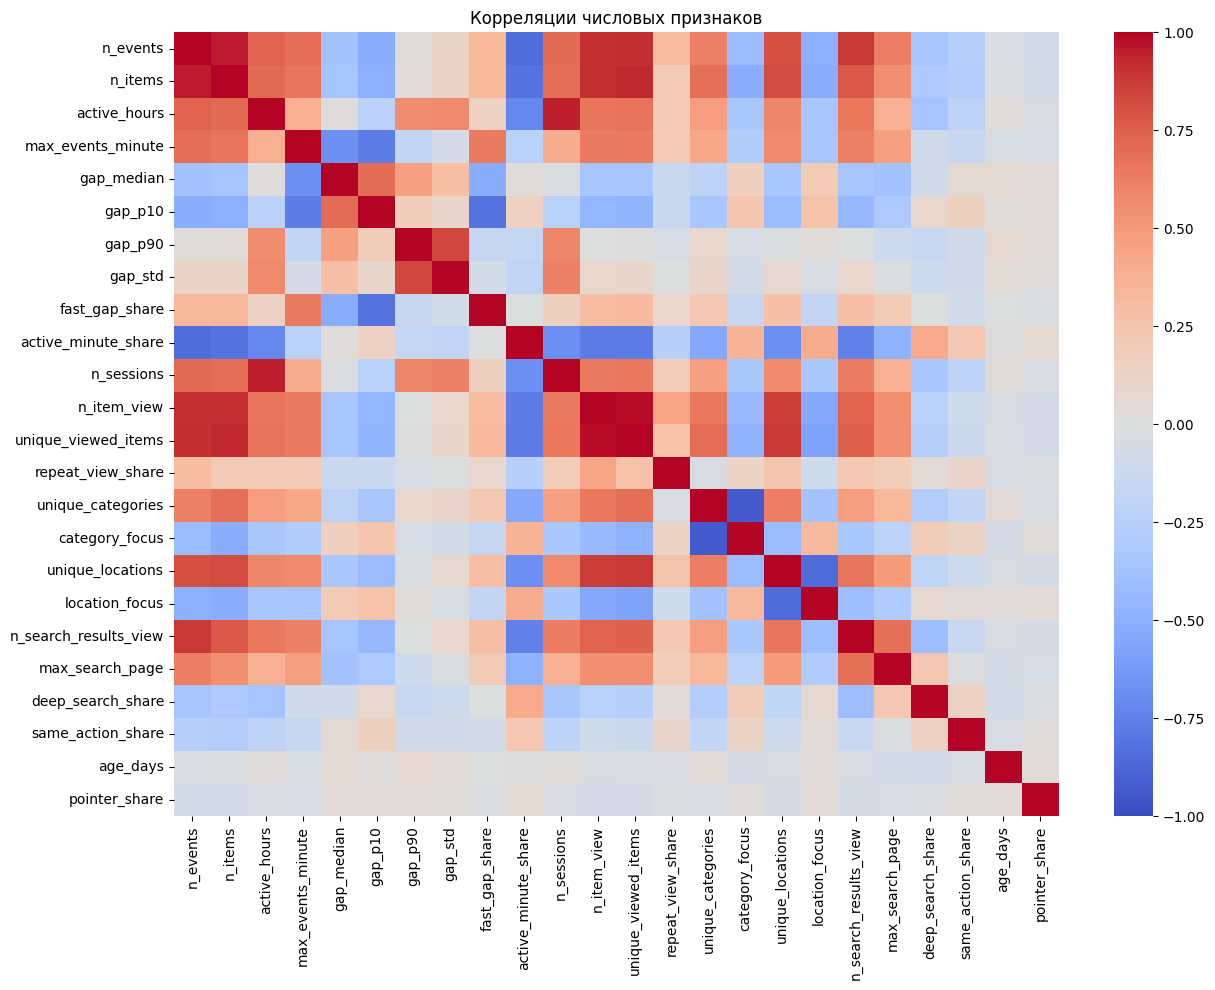

,level_0,level_1,Корреляция
198,n_item_view,unique_viewed_items,0.984
0,n_events,n_items,0.960
52,active_hours,n_sessions,0.951
231,unique_categories,category_focus,-0.935
33,n_items,unique_viewed_items,0.934
11,n_events,unique_viewed_items,0.916
10,n_events,n_item_view,0.914
32,n_items,n_item_view,0.912
17,n_events,n_search_results_view,0.889
213,unique_viewed_items,unique_locations,0.885


In [231]:
correlation_columns = [
    'n_events', 'n_items', 'active_hours', 'max_events_minute',
    'gap_median', 'gap_p10', 'gap_p90', 'gap_std',
    'fast_gap_share', 'active_minute_share', 'n_sessions',
    'n_item_view', 'unique_viewed_items', 'repeat_view_share',
    'unique_categories', 'category_focus',
    'unique_locations', 'location_focus',
    'n_search_results_view', 'max_search_page', 'deep_search_share',
    'same_action_share', 'age_days', 'pointer_share'
]

feature_correlation = analysis[correlation_columns].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    feature_correlation,
    vmin=-1,
    vmax=1,
    center=0,
    cmap='coolwarm',
    ax=ax
)
ax.set_title('Корреляции числовых признаков')
plt.tight_layout()
plt.show()

upper_triangle = feature_correlation.where(
    np.triu(np.ones(feature_correlation.shape), k=1).astype(bool)
)

strong_correlations = (
    upper_triangle.stack()
    .rename('Корреляция')
    .reset_index()
)
strong_correlations = strong_correlations.loc[
    strong_correlations['Корреляция'].abs().ge(0.85)
].sort_values('Корреляция', key=lambda x: x.abs(), ascending=False)

display(strong_correlations.round(3))

Корреляция n_item_view и unique_viewed_items равна 0,984. Корреляция active_hours и n_sessions равна 0,951. Корреляция unique_categories и category_focus равна -0,935.

Похожие признаки пока оставляем. При разборе важности учитываем, что модель может распределить вклад между ними.

### Что происходит у самых необычных кук?

Берём верхний процент n_events, max_events_minute, max_search_page и unique_locations. Для gap_median берём нижний процент. В каждой группе считаем число кук и долю положительного класса.

In [232]:
extreme_rows = []

for feature in ['n_events', 'max_events_minute', 'max_search_page', 'unique_locations']:
    threshold = analysis[feature].quantile(0.99)
    subset = analysis.loc[analysis[feature].ge(threshold)]
    extreme_rows.append([
        feature,
        'верхний 1%',
        threshold,
        len(subset),
        subset['target'].mean() * 100
    ])

gap_threshold = analysis['gap_median'].quantile(0.01)
fast_subset = analysis.loc[analysis['gap_median'].le(gap_threshold)]
extreme_rows.append([
    'gap_median',
    'нижний 1%',
    gap_threshold,
    len(fast_subset),
    fast_subset['target'].mean() * 100
])

extreme_table = pd.DataFrame(
    extreme_rows,
    columns=['Признак', 'Хвост', 'Граница', 'Кук', 'Доля ботов, %']
)
display(extreme_table.round(2))

display(
    analysis[[
        'n_events', 'max_events_minute', 'gap_median',
        'max_search_page', 'unique_locations', 'target'
    ]]
    .sort_values('n_events', ascending=False)
    .head(15)
)

,Признак,Хвост,Граница,Кук,"Доля ботов, %"
0,n_events,верхний 1%,86.0,96,41.67
1,max_events_minute,верхний 1%,8.0,100,86.00
2,max_search_page,верхний 1%,21.0,85,84.71
3,unique_locations,верхний 1%,15.0,102,54.90
4,gap_median,нижний 1%,6.5,93,49.46


,n_events,max_events_minute,gap_median,max_search_page,unique_locations,target
cookie_id,,,,,,
ck_71bf885006274d6a,165,11,6.0,41.0,25,1
ck_3461e957e7ed4c93,157,8,8.0,36.0,24,1
ck_61e7bd334a1356a0,140,11,6.0,31.0,21,1
ck_57281faf7f5f69ea,138,8,8.0,25.0,21,1
ck_352bfd2d163c99da,137,4,47.5,7.0,15,0
ck_9e7c387cfa1dc3c5,134,16,4.0,34.0,16,1
ck_25907a736fb5e5d0,133,7,12.0,20.0,19,1
ck_6a0824a0cdb3771c,132,8,9.0,39.0,14,1
ck_a8ee9b23f43520e5,126,4,38.0,10.0,14,0


В верхнем проценте max_events_minute доля ботов равна 86,00%. Для max_search_page она равна 84,71%, для n_events - 41,67%, для unique_locations - 54,90%. Среди кук с самыми короткими медианными паузами доля ботов равна 49,46%.

Каждая группа содержит 85-102 куки. Такие признаки полезны для ранжирования, но не обеспечивают recall 70% самостоятельно.

cookies  events_median  gap_median  age_median
window_start_ts target                                                
2026-04-06      0           704           11.0       60.00       62.75
                1            68           16.0       27.00        3.37
2026-04-07      0           738           12.0       60.75       59.23
                1            59           16.0       31.00       48.57
2026-04-08      0           764           12.0       62.25       63.63
                1            70           21.0       20.75       39.25
2026-04-09      0           836           11.0       59.50       67.01
                1            66           17.5       27.50        3.98
2026-04-10      0           830           12.0       61.00       60.31
                1            82           26.0       21.00       26.66
2026-04-11      0           817           12.0       63.00       59.95
                1            79           19.0       28.50       20.95
2026-04-12      0           750           11.0       63.50       64.96
                1            67           26.0       24.00        3.08
2026-04-13      0           790           12.0       62.00       63.69
                1            53           23.0       18.50       38.39
2026-04-14      0           756           12.0       61.00       67.58
                1            70           19.5       25.50        4.07
2026-04-15      0           736           11.0       63.00       63.44
                1            65           19.0       27.00       29.10
2026-04-16      0           680           11.0       59.00       65.77
                1            60           21.0       25.75       35.21

,cookies,bots,bot_rate
window_start_ts,,,
2026-04-06,772,68,8.81
2026-04-07,797,59,7.40
2026-04-08,834,70,8.39
2026-04-09,902,66,7.32
2026-04-10,912,82,8.99
2026-04-11,896,79,8.82
2026-04-12,817,67,8.20
2026-04-13,843,53,6.29
2026-04-14,826,70,8.47


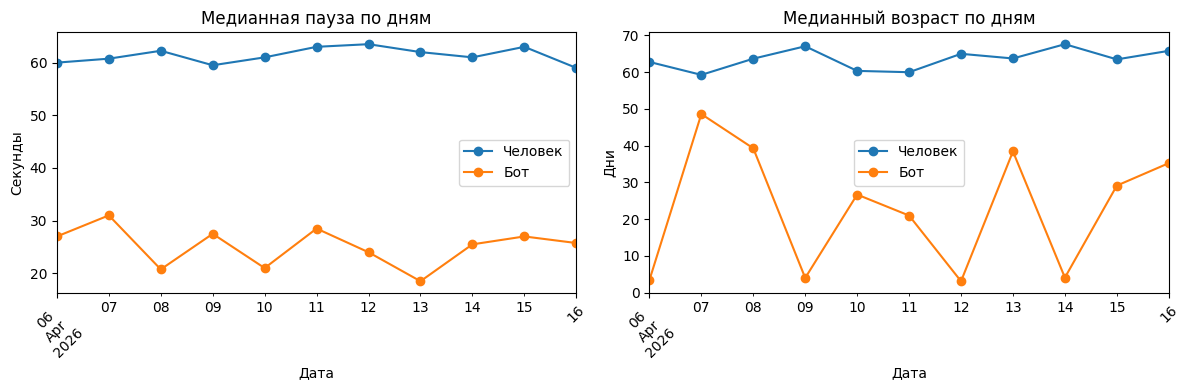

In [233]:
daily_behavior = analysis.groupby(['window_start_ts', 'target']).agg(
    cookies=('target', 'size'),
    events_median=('n_events', 'median'),
    gap_median=('gap_median', 'median'),
    age_median=('age_days', 'median')
)
display(daily_behavior.round(2))

daily_target = analysis.groupby('window_start_ts')['target'].agg(
    cookies='size',
    bots='sum',
    bot_rate='mean'
)
daily_target['bot_rate'] *= 100
display(daily_target.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

daily_behavior['gap_median'].unstack('target').plot(marker='o', ax=axes[0])
axes[0].set(title='Медианная пауза по дням', xlabel='Дата', ylabel='Секунды')

daily_behavior['age_median'].unstack('target').plot(marker='o', ax=axes[1])
axes[1].set(title='Медианный возраст по дням', xlabel='Дата', ylabel='Дни')

for ax in axes:
    ax.legend(['Человек', 'Бот'])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Доля положительного класса меняется по дням. Случайное разбиение использовать нельзя. Разница в паузах выглядит устойчивее. Разница в возрасте сильнее зависит от дня. Итоговую оценку проводим на 17-19 апреля.

## Похожи ли train и test без использования меток test?

Сравниваем числовые признаки всех кук. target к test не присоединяется.

In [234]:
shift_columns = [
    'n_events',
    'n_items',
    'age_days',
    'gap_median',
    'max_search_page',
    'pointer_share',
    'category_focus'
]

shift_summary = cookie_features.groupby('dataset')[shift_columns].agg(
    ['count', 'median', lambda x: x.quantile(0.95)]
)
shift_summary.columns = [
    f'{column}_{stat if stat != "<lambda_0>" else "p95"}'
    for column, stat in shift_summary.columns
]

display(shift_summary.T)

dataset,test,train
n_events_count,4909.000000,11091.000000
n_events_median,12.000000,12.000000
n_events_p95,55.000000,52.000000
n_items_count,4909.000000,11091.000000
n_items_median,6.000000,6.000000
n_items_p95,29.000000,28.000000
age_days_count,4909.000000,11091.000000
age_days_median,59.631076,60.759178
age_days_p95,199.335947,201.019734
gap_median_count,4804.000000,10837.000000


### Насколько полностью совпадают распределения train и test?

Одинаковых медиан недостаточно. Для каждого числового признака считаем статистику Колмогорова-Смирнова и разницу долей пропусков. Чем ближе KS к нулю, тем больше похожи распределения. При большом числе строк p-value может быть маленьким даже для слабого сдвига, поэтому основной ориентир здесь - размер KS.

In [235]:
from scipy.stats import ks_2samp

shift_columns = [
    'n_events', 'n_items', 'age_days', 'active_hours',
    'max_events_minute', 'gap_median', 'gap_p10', 'gap_p90',
    'fast_gap_share', 'active_minute_share', 'n_sessions',
    'unique_categories', 'category_focus',
    'unique_locations', 'location_focus',
    'max_search_page', 'deep_search_share',
    'same_action_share', 'pointer_share'
]

shift_rows = []

for feature in shift_columns:
    train_values = cookie_features.loc[
        cookie_features['dataset'].eq('train'), feature
    ].dropna()
    test_values = cookie_features.loc[
        cookie_features['dataset'].eq('test'), feature
    ].dropna()
    ks_result = ks_2samp(train_values, test_values)
    train_missing = cookie_features.loc[
        cookie_features['dataset'].eq('train'), feature
    ].isna().mean() * 100
    test_missing = cookie_features.loc[
        cookie_features['dataset'].eq('test'), feature
    ].isna().mean() * 100

    shift_rows.append([
        feature,
        train_values.median(),
        test_values.median(),
        ks_result.statistic,
        ks_result.pvalue,
        train_missing,
        test_missing,
        test_missing - train_missing
    ])

distribution_shift = pd.DataFrame(
    shift_rows,
    columns=[
        'Признак', 'Медиана train', 'Медиана test', 'KS', 'p-value',
        'Пропуски train, %', 'Пропуски test, %', 'Разница пропусков, п.п.'
    ]
).sort_values('KS', ascending=False)

display(distribution_shift.round(4))

,Признак,Медиана train,Медиана test,KS,p-value,"Пропуски train, %","Пропуски test, %","Разница пропусков, п.п."
16,deep_search_share,0.2500,0.2500,0.0257,0.3421,62.2216,60.7863,-1.4353
15,max_search_page,4.0000,4.0000,0.0256,0.0330,8.3040,8.8613,0.5572
12,category_focus,0.8000,0.8000,0.0209,0.1251,7.3844,6.9464,-0.4379
7,gap_p90,1472.6000,1415.3500,0.0206,0.1157,2.2901,2.1389,-0.1512
5,gap_median,58.0000,56.2500,0.0205,0.1196,2.2901,2.1389,-0.1512
8,fast_gap_share,0.0833,0.0909,0.0202,0.1298,2.2901,2.1389,-0.1512
17,same_action_share,0.2727,0.2735,0.0169,0.3847,16.6712,16.6022,-0.0690
6,gap_p10,16.1000,15.7000,0.0154,0.4063,2.2901,2.1389,-0.1512
13,unique_locations,3.0000,3.0000,0.0125,0.6532,0.0000,0.0000,0.0000
4,max_events_minute,2.0000,2.0000,0.0123,0.6741,0.0000,0.0000,0.0000


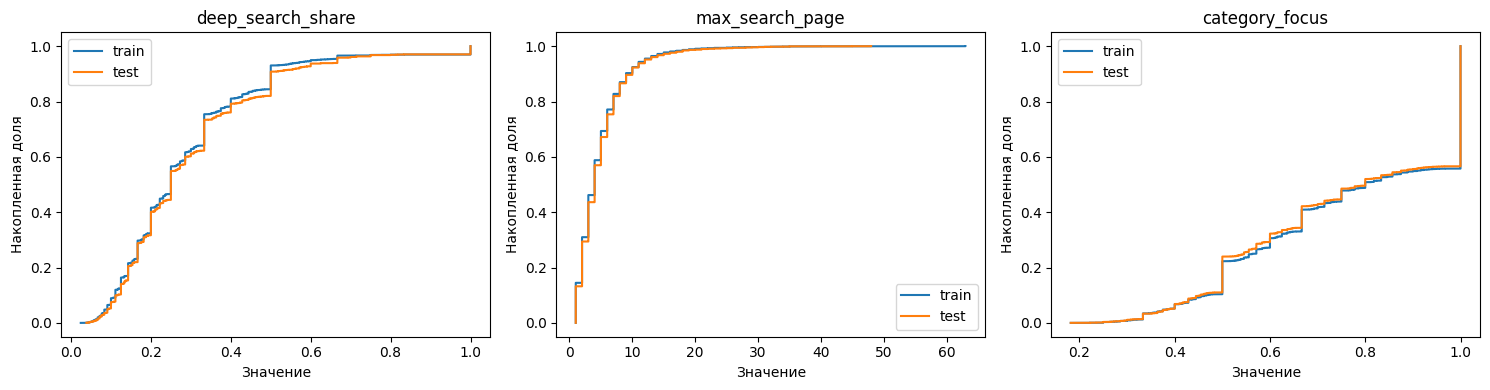

In [236]:
largest_shift = distribution_shift.head(3)['Признак'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for feature, ax in zip(largest_shift, axes):
    for dataset, label in [('train', 'train'), ('test', 'test')]:
        values = cookie_features.loc[
            cookie_features['dataset'].eq(dataset), feature
        ].dropna().sort_values().to_numpy()
        cumulative_share = np.arange(1, len(values) + 1) / len(values)
        ax.step(values, cumulative_share, where='post', label=label)
    ax.set(title=feature, xlabel='Значение', ylabel='Накопленная доля')
    ax.legend()

plt.tight_layout()
plt.show()

Для всех проверенных признаков KS не превышает 0,0257. Самые большие значения получили deep_search_share и max_search_page, но их сдвиг всё равно небольшой. Максимальная разница долей пропусков равна 1,44 процентного пункта у deep_search_share. По этим проверкам train и test похожи. Временная валидация всё равно нужна, потому что небольшой общий сдвиг не гарантирует одинаковую связь признаков с target.

Медианное число событий и возраст куки близки в train и test. Дополнительно проверяем платформы, новые значения и форму числовых распределений.

In [237]:
platform_shift = pd.crosstab(
    cookie_features['platform'],
    cookie_features['dataset'],
    normalize='columns'
).mul(100)

platform_shift['test_minus_train'] = platform_shift['test'] - platform_shift['train']
display(platform_shift.round(2))

dataset,test,train,test_minus_train
platform,,,
android,40.56,41.43,-0.87
ios,5.19,5.22,-0.03
web,54.25,53.35,0.90


Состав платформ немного меняется. Изменение влияет на заполненность координат.

Проверяем значения категориальных полей, которые встречаются только в test. item_id не включаем, потому что новые объявления ожидаемы.

In [238]:
event_dataset = events.merge(
    meta[['cookie_id', 'dataset']],
    on='cookie_id',
    validate='many_to_one'
)

new_values = []

for column in ['platform', 'user_agent', 'item_category', 'item_location', 'seller_type', 'search_query']:
    train_values = event_dataset.loc[
        event_dataset['dataset'].eq('train'), column
    ].dropna()
    test_values = event_dataset.loc[
        event_dataset['dataset'].eq('test'), ['cookie_id', column]
    ].dropna()

    unseen = ~test_values[column].isin(train_values.unique())

    new_values.append({
        'Поле': column,
        'Уникальных в train': train_values.nunique(),
        'Уникальных в test': test_values[column].nunique(),
        'Новых значений в test': test_values.loc[unseen, column].nunique(),
        'Доля событий с новым значением, %': unseen.mean() * 100,
        'Кук с новым значением': test_values.loc[unseen, 'cookie_id'].nunique()
    })

display(pd.DataFrame(new_values).round(2))

,Поле,Уникальных в train,Уникальных в test,Новых значений в test,"Доля событий с новым значением, %",Кук с новым значением
0,platform,3,3,0,0.0,0
1,user_agent,148,148,0,0.0,0
2,item_category,15,15,0,0.0,0
3,item_location,40,40,0,0.0,0
4,seller_type,2,2,0,0.0,0
5,search_query,120,120,0,0.0,0


В выбранных полях нет значений test, отсутствующих в train. Кодировщик всё равно должен обрабатывать неизвестные категории. Они могут появиться на новых данных.

Словари и параметры преобразований определяются только на обучающей части.

## Финальная проверка собранной таблицы

Проверяем размер, ключи, временные границы и числовые значения.

In [239]:
window_check = events[['cookie_id', 'event_ts']].merge(
    meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
    on='cookie_id',
    validate='many_to_one'
)

inside_window = (
    window_check['event_ts'].ge(window_check['window_start_ts']) &
    window_check['event_ts'].lt(window_check['window_end_ts'])
).all()

numeric_values = cookie_features.select_dtypes('number').to_numpy()
share_columns = [
    column for column in cookie_features.columns
    if column.endswith('_share') or column.endswith('_focus') or column.startswith('share_')
]

checks = pd.DataFrame({
    'Проверка': [
        'Одна строка на cookie_id',
        'Сохранены все куки train и test',
        'target отсутствует в общей таблице признаков',
        'Все события находятся внутри своего окна',
        'Нет бесконечных числовых значений',
        'Доли находятся между 0 и 1',
        'У кук с одним событием gap_median отсутствует',
        'При отсутствии просмотров contacts_per_view отсутствует'
    ],
    'Результат': [
        cookie_features.index.is_unique,
        len(cookie_features) == len(meta),
        'target' not in cookie_features.columns,
        inside_window,
        not np.isinf(numeric_values).any(),
        cookie_features[share_columns].apply(
            lambda x: x.dropna().between(0, 1).all()
        ).all(),
        cookie_features.loc[
            cookie_features['n_events'].eq(1), 'gap_median'
        ].isna().all(),
        cookie_features.loc[
            cookie_features['n_item_view'].eq(0), 'contacts_per_view'
        ].isna().all()
    ]
})

display(checks)
print('Размер таблицы признаков:', cookie_features.shape)

,Проверка,Результат
0,Одна строка на cookie_id,True
1,Сохранены все куки train и test,True
2,target отсутствует в общей таблице признаков,True
3,Все события находятся внутри своего окна,True
4,Нет бесконечных числовых значений,True
5,Доли находятся между 0 и 1,True
6,У кук с одним событием gap_median отсутствует,True
7,При отсутствии просмотров contacts_per_view от...,True


Размер таблицы признаков: (16000, 60)


## Что узнали и что проверять моделью

Наблюдения на периоде разработки

- положительные куки совершают больше событий и действуют с меньшими паузами
- у них больше коротких пауз и меньше длинных пауз
- они сильнее сосредоточены на одной категории и охватывают больше локаций
- поиск у них глубже
- они моложе
- на web у них реже заполнены координаты
- пропуски в характеристиках объявления почти не различаются между классами
- отсутствие контактов не отделяет ботов от людей
- полные последовательности действий у ботов повторяются не чаще
- маркеры автоматизации в User-Agent повышают долю положительного класса, но охватывают мало кук
- полные дубли искажают признаки ритма
- экстремальная скорость и глубина поиска связаны с target, но охватывают мало кук
- максимальный KS между train и test равен 0,0257

Признаки для первой модели

- n_events, количества действий и число уникальных объявлений
- квантили пауз, разброс пауз, доля быстрых пауз, максимум событий за минуту и число сессий
- доли просмотров, поиска, контактов, фото и избранного
- повторные просмотры, категории, локации и концентрация интересов
- число запросов, максимальная страница и доля глубоких страниц
- возраст куки, платформа, User-Agent и заполненность координат

Подбор проводится на 6-16 апреля. Период 17-19 апреля используется один раз после выбора признаков и модели. Test нужен только для финального предсказания. Доверительный интервал Precision @ Recall >= 0.70 можно посчитать после появления предсказаний.

In [240]:
feature_overview = pd.DataFrame({
    'dtype': cookie_features.dtypes.astype(str),
    'missing_percent': cookie_features.isna().mean().mul(100).round(2),
    'unique_values': cookie_features.nunique(dropna=True)
})

display(feature_overview)

,dtype,missing_percent,unique_values
dataset,object,0.00,2
period,object,0.00,3
window_start_ts,datetime64[ns],0.00,21
age_days,float64,0.00,15965
n_events,int64,0.00,138
n_items,int64,0.00,75
platform,string,0.00,3
active_hours,int64,0.00,18
max_events_minute,int64,0.00,21
gap_median,float64,2.24,1506
